In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def plot_es(es, color, ax=None, marker='o', **kwargs):
    norm = np.max(es[0])
    for k in es:
        es[k] /= norm
    if ax is None:
        fig, ax = plt.subplots()
    for k in es.keys():
        ax.plot(k * np.ones(len(es[k])), -np.log(np.abs(es[k])), lw=0, markerfacecolor='none', marker=marker, color=color, **kwargs)
        print(-np.log(np.abs(es[k])))
    return ax

[-0.          0.99627281  1.05674199  1.14977717  1.17413285  1.25573505
  1.42643317  1.57762447]
[0.19149062 1.15955235 1.26930268 1.34926665 1.39752192 1.46617813
 1.54549732 1.65918398]
[0.38027413 0.4195584  1.34894344 1.37542419 1.58237689 1.63684877
 1.70767941 1.75827538]
[0.60923383 0.63651192 0.74145854 1.56504113 1.61093015 1.69055954
 1.85677051 1.89926356]
[0.80142565 0.86158932 0.93563377 1.02001567 1.21930903 1.74818624
 1.82330934 1.89224895]
[-0.          1.06383567  1.15702418  1.17717727  1.20940665  1.26804823
  1.44145253  1.58746008]
[0.19095537 1.27832376 1.35868068 1.37377477 1.41122896 1.47698468
 1.55614786 1.67135187]
[0.38203951 0.42074008 1.56571398 1.57955092 1.60694819 1.65153079
 1.72369152 1.77152101]
[0.61263404 0.64024203 0.74637573 1.7841776  1.82075169 1.87574673
 1.90355475 1.91471891]
[0.80629321 0.86722241 0.94260597 1.02494105 1.2346585  1.97132278
 2.03860237 2.102688  ]
[-0.          1.05381153  1.14796122  1.17238802  1.25490067  1.42120892
 

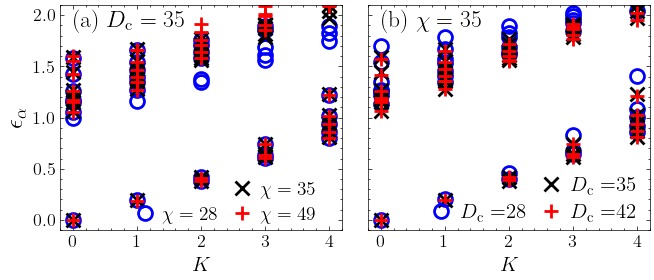

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os


plt.style.use("science")  # requires SciencePlots; remove if not installed
plt.rcParams["legend.handletextpad"] = 0.3
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13


# Common settings
L = 5
D = 7
markers = ['o', 'x', '+']
colors  = ['blue', 'black', 'red']

fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

# --- Left: vary environment chi at fixed D_compress ---
D_compress = 35
for i, env_chi in enumerate([28, 35, 49]):
    filename = f"./es/es_APBC_site_0_dirn_(0,1)_L_{L:d}_D_{D:d}_D_compress_{D_compress:d}_chi_{env_chi:d}_n=0"
    if os.path.isfile(filename):
        with open(filename, "rb") as f:
            es = pickle.load(f)
        # print(filename)
        plot_es(es, color=colors[i], ax=axes[0], marker=markers[i], label=rf"$\chi={env_chi:d}$", markersize=10, markeredgewidth=2)


from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
seen = set()
h, l = [], []
for hd, lb in zip(handles, labels):
    if lb not in seen:
        seen.add(lb)
        h.append(hd)
        l.append(lb)

# --- build 2-column layout: col1=[first], col2=[rest] ---
spacer = Line2D([], [], linestyle='None', marker=None, alpha=0)  # invisible
h2 = [spacer, h[0]] + h[1:]
l2 = ['', l[0]] + l[1:]

ax = axes[0]
ax.legend(
    h2, l2,
    loc=3, bbox_to_anchor=(0.17, -0.05),
    ncol=2, handletextpad=-0.1, fontsize=14,
    labelspacing=0.4, columnspacing=0.2, frameon=False
)


axes[0].set_xlabel(r"$K$", fontsize=15)
axes[0].set_ylabel(r"$\epsilon_{\alpha}$", fontsize=18)
# axes[0].set_title(r"$D_{\mathrm{c}}=36$, vary $\chi$", fontsize=13)

# --- Right: vary D_compress at fixed environment chi ---
markers = ['o', 'x', '+']
colors  = ['blue', 'black', 'red']

env_chi = 35
for i, D_compress in enumerate([28, 35, 42]):
    with open(f"./es/es_APBC_site_0_dirn_(0,1)_L_{L:d}_D_{D:d}_D_compress_{D_compress:d}_chi_{env_chi:d}_n=0", "rb") as f:
        es = pickle.load(f)
    plot_es(es, color=colors[i], ax=axes[1], marker=markers[i],
            label=r"$D_{\mathrm{c}}=$" + f"{D_compress:d}", markersize=10, markeredgewidth=2)

# ks = np.linspace(-0.2, 4.5, 30)
# axes[1].plot(ks, 0.28*ks+0.24, ls='dashed', lw=2, color='grey')

from matplotlib.lines import Line2D
handles, labels = axes[1].get_legend_handles_labels()
seen = set()
h, l = [], []
for hd, lb in zip(handles, labels):
    if lb not in seen:
        seen.add(lb)
        h.append(hd)
        l.append(lb)

# --- build 2-column layout: col1=[first], col2=[rest] ---
spacer = Line2D([], [], linestyle='None', marker=None, alpha=0)  # invisible
h2 = [spacer, h[0]] + h[1:]
l2 = ['', l[0]] + l[1:]

ax = axes[1]
ax.legend(
    h2, l2,
    loc=3, bbox_to_anchor=(0.12, -0.05),
    ncol=2, handletextpad=-0.1, fontsize=15,
    labelspacing=0.4, columnspacing=0.2, frameon=False
)

axes[1].set_xlabel(r"$K$", fontsize=15)
axes[0].set_ylim([-0.1, 2.1])

# axes[1].set_title(r"$\chi=49$, vary $D_{\mathrm{c}}$", fontsize=13)

# Optional: y-limit
# axes[0].set_ylim([-0.1, 2.4])
# after creating fig, axes = plt.subplots(1, 2, ...)
axes[0].text(0.05, 0.98, r"(a) $D_{\text{c}}=35$", transform=axes[0].transAxes,
             ha="left", va="top", fontsize=17, fontweight="extra bold")
axes[1].text(0.05, 0.98, "(b) $\chi=35$", transform=axes[1].transAxes,
             ha="left", va="top", fontsize=17, fontweight="extra bold")


plt.tight_layout()
plt.savefig("FCI_3x3_N3_D_7_edge_spectrum.pdf")



[-0.          1.06383567  1.15702418  1.17717727  1.20940665  1.26804823
  1.44145253  1.58746008]
[0.19095537 1.27832376 1.35868068 1.37377477 1.41122896 1.47698468
 1.55614786 1.67135187]
[0.38203951 0.42074008 1.56571398 1.57955092 1.60694819 1.65153079
 1.72369152 1.77152101]
[0.61263404 0.64024203 0.74637573 1.7841776  1.82075169 1.87574673
 1.90355475 1.91471891]
[0.80629321 0.86722241 0.94260597 1.02494105 1.2346585  1.97132278
 2.03860237 2.102688  ]
[-0.          1.40822344  1.52231915  1.61758417  1.72971962  1.88323501
  1.94875321  2.01771048]
[0.34524979 1.61999481 1.77910048 1.83377084 1.99001699 2.04331644
 2.14610353 2.1974132 ]
[0.55000416 0.7173647  2.01262449 2.1386735  2.20288159 2.29138095
 2.3369049  2.40056034]
[0.79064979 0.98460034 1.11889593 2.27864383 2.42417897 2.53085024
 2.58351087 2.58400388]
[1.12365435 1.1311043  1.32758325 1.46739495 1.55584419 2.51638562
 2.79062602]
[-0.          1.03447754  1.17948677  1.27697677  1.55672029  1.67286042
  2.28245203

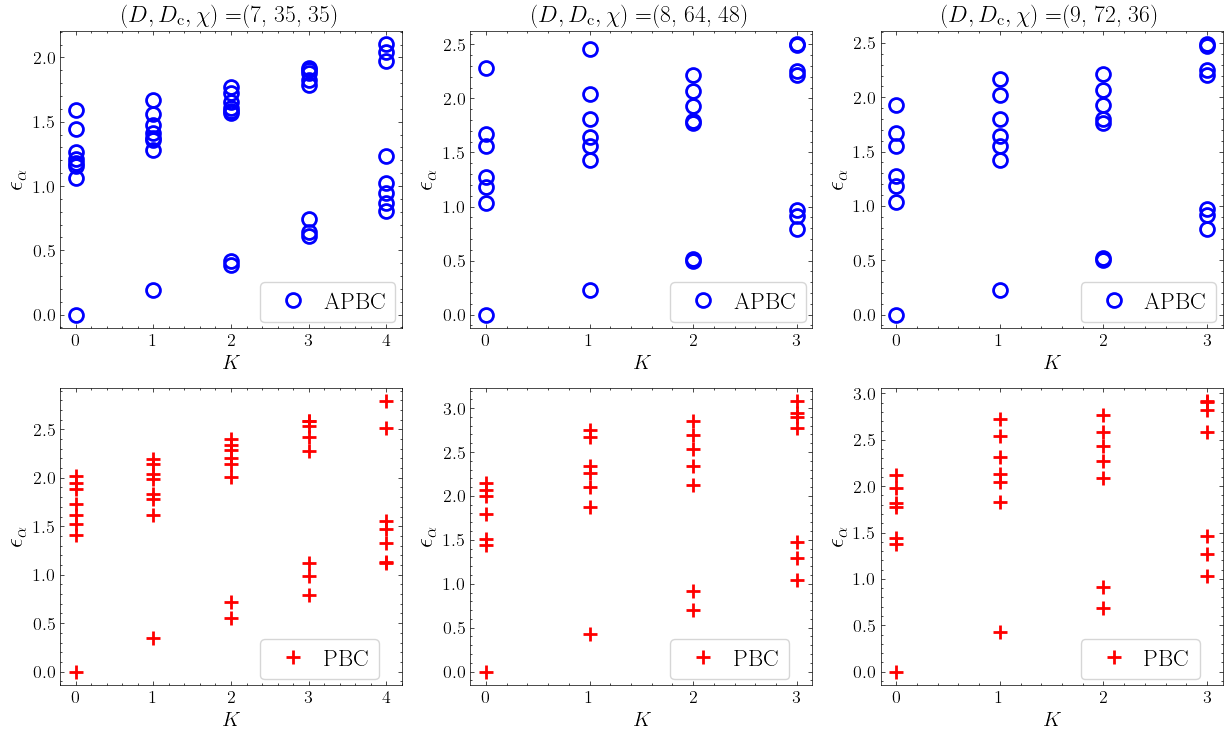

In [9]:
plt.style.use("science")

fig, axes = plt.subplots(2, 3, figsize=(15,8.5))

for i, (D, env_chi, D_compress, L) in enumerate([(7, 35, 35, 5), (8, 48, 64, 4), (9, 36, 72, 4)]):
# for i, (D, env_chi, D_compress, L) in enumerate([(4, 32, 16, 5), (8, 48, 64, 4), (9, 36, 72, 4)]):
    markers = ['o', '+']
    colors=['blue', 'red', 'black']
    ax = axes[0][i]
    with open(f"./es/es_APBC_site_0_dirn_(0,1)_L_{L:d}_D_{D:d}_D_compress_{D_compress:d}_chi_{env_chi:d}_n=0", "rb") as f:
        es = pickle.load(f)
    ax = plot_es(es, color=colors[0], ax=ax, marker=markers[0], markersize=10, markeredgewidth=2, label="APBC")
    ax.set_title(r"$(D, D_{\text{c}}, \chi)=$" + f"({D:d}, {D_compress:d}, {env_chi:d})", fontsize=17)
    ax.set_ylabel(r"$\epsilon_{\alpha}$", fontsize=18)
    ax.set_xlabel(r"$K$", fontsize=15)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=17, loc=3, bbox_to_anchor=(0.55, -0.02), frameon=True)

    ax = axes[1][i]
    with open(f"./es/es_PBC_site_0_dirn_(0,1)_L_{L:d}_D_{D:d}_D_compress_{D_compress:d}_chi_{env_chi:d}_n=0", "rb") as f:
        es = pickle.load(f)
    ax = plot_es(es, color=colors[1], ax=ax, marker=markers[1], markersize=10, markeredgewidth=2, label="PBC")
    # if i <= 1:
    #     with open(f"FCI_env/es_PBC_site_0_dirn_(0,1)_L_{L:d}_D_{D:d}_D_compress_{D_compress:d}_chi_{env_chi:d}_n=0", "rb") as f:
    #         es = pickle.load(f)
    #     ax = plot_es(es, color=colors[1], ax=ax, marker=markers[1], label="PBC")


    # ks = np.linspace(-0.2, 4.5, 30)
    # ax.plot(ks, 0.45*ks+0.2, ls='dashed', lw=2, color='black')
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=17, loc=3, bbox_to_anchor=(0.55, -0.02), frameon=True)
    ax.set_xlabel(r"$K$", fontsize=15)
    ax.set_ylabel(r"$\epsilon_{\alpha}$", fontsize=18)
    # ax.set_ylim([-0.1, 2.8])

plt.savefig("es_all.pdf")


[-0.          4.04037364  4.53042549  4.95019073  5.22151733  5.23598481
  5.24071442  5.25123174]
[3.96632131 4.48693155 4.88496496 5.21960834 5.23579501 5.25085494
 5.29402638 7.41545941]
[3.7663934  4.46004058 4.83710232 5.21517352 5.23594715 5.25635724
 5.61212448 7.42758382]
[3.73360833 4.46822927 4.83642141 5.21434706 5.23600399 5.25718288
 5.80468571 7.39709344]
[3.88070876 4.49676262 4.86193488 5.21816023 5.23606378 5.25304525
 5.66495708 7.37459802]
[-0.          1.45236688  1.5215468   1.63775108  1.69580298  1.76019249
  2.04538262  2.37524548]
[0.36021591 1.6594777  1.81275292 1.92447746 1.9998512  2.03856757
 2.09591284 2.21267455]
[0.55622255 0.73473679 2.02346536 2.20553262 2.26469323 2.29345613
 2.37189647 2.49838645]
[0.8081374  0.99132314 1.19256778 2.25443443 2.49328157 2.51884721
 2.59012777 2.66766781]
[1.11859057 1.17593643 1.27855512 1.47564543 1.81430925 2.69351706
 2.74837389 2.8290512 ]
[-0.          1.78466215  2.12385541  2.19738344  2.67286743  2.80301707
 

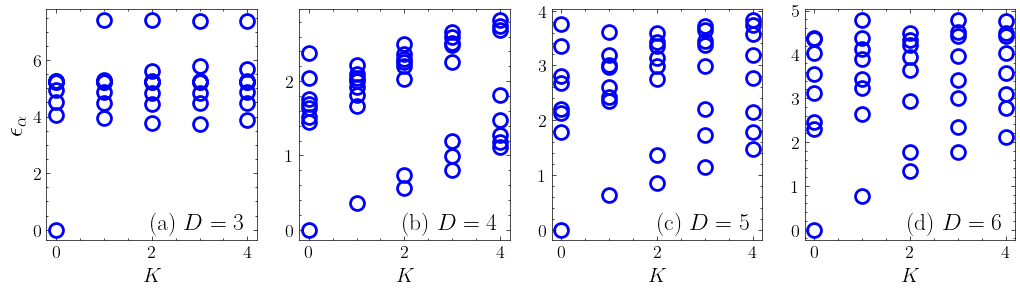

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os


plt.style.use("science")  # requires SciencePlots; remove if not installed
plt.rcParams["legend.handletextpad"] = 0.3
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13


# Common settings
L = 5
markers = ['o', 'x', '+']
colors  = ['blue', 'black', 'red']

# fig, axes = plt.subplots(1, 5, figsize=(15.5, 3))
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3))

configs = [
    (3, 24, 48),   # (D, D_compress, env_chi)
    (4, 32, 32),
    (5, 30, 50),
    (6, 30, 36),
    # (7, 35, 49),
]
labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

for i, (D, D_compress, env_chi) in enumerate(configs):
    filename = f"./es/es_APBC_site_0_dirn_(0,1)_L_{L:d}_D_{D:d}_D_compress_{D_compress:d}_chi_{env_chi:d}_n=0"
    if os.path.isfile(filename):
        with open(filename, "rb") as f:
            es = pickle.load(f)
        plot_es(es, color=colors[0], ax=axes[i], marker=markers[0],
                label=rf"$\chi={env_chi:d}$", markersize=10, markeredgewidth=2)
    axes[i].set_xlabel(r"$K$", fontsize=15)
    axes[i].text(0.95, 0.02, rf"{labels[i]} $D={D}$", transform=axes[i].transAxes,
                 ha="right", va="bottom", fontsize=17, fontweight="extra bold")

axes[0].set_ylabel(r"$\epsilon_{\alpha}$", fontsize=18)
plt.savefig("es_D_3_to_6.pdf")
